<a href="https://colab.research.google.com/github/keirabasma/Formation-IA/blob/main/IA__RIHEL_WORKSHOP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RIHEL FATMA ZOHRA « Génie des procédés : procédés organiques »

In [30]:
# Importer les bibliothèques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use('seaborn-v0_8')

In [31]:
#Importer le fichier CSV depuis Google Colab
import pandas as pd
from google.colab import files
uploaded = files.upload()

# Lire le fichier CSV
df = pd.read_csv('AAPL.csv', parse_dates=['Date'])


#Vérification que le dataset est chargé correctement
print("Dataset chargé avec succès !")
print("Dimensions :", df.shape)
print("Colonnes :", df.columns)
print(df.head())

Saving AAPL.csv to AAPL (2).csv
Dataset chargé avec succès !
Dimensions : (184, 7)
Colonnes : Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')
        Date        Open        High         Low       Close   Adj Close  \
0 2014-09-29  100.589996  100.690002   98.040001   99.620003   93.514290   
1 2014-10-06   99.949997  102.379997   98.309998  100.730003   94.556244   
2 2014-10-13  101.330002  101.779999   95.180000   97.669998   91.683792   
3 2014-10-20   98.320000  105.489998   98.220001  105.220001   98.771042   
4 2014-10-27  104.849998  108.040001  104.699997  108.000000  101.380676   

      Volume  
0  142718700  
1  280258200  
2  358539800  
3  358532900  
4  220230600  


In [32]:

# Manipulations de données avec Pandas et NumPy

print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       184 non-null    datetime64[ns]
 1   Open       184 non-null    float64       
 2   High       184 non-null    float64       
 3   Low        184 non-null    float64       
 4   Close      184 non-null    float64       
 5   Adj Close  184 non-null    float64       
 6   Volume     184 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 10.2 KB
None
                                Date        Open        High         Low  \
count                            184  184.000000  184.000000  184.000000   
mean   2016-06-30 11:28:41.739130368  127.040245  129.918098  124.340381   
min              2014-09-29 00:00:00   92.389999   93.769997   89.470001   
25%              2015-08-15 06:00:00  108.882499  112.362499  106.152502   
50%              2

In [33]:
# Créer une colonne
df['Daily_Return'] = df['Close'].pct_change()

In [34]:
# Moyenne mobile sur 20 jours et 50 jours pour le prix de clôture
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()


In [35]:
# Moyenne et écart-type du prix de clôture avec NumPy
mean_close = np.mean(df['Close'])
std_close = np.std(df['Close'])
print("Prix moyen de clôture :", round(mean_close, 2))
print("Écart-type du prix de clôture :", round(std_close, 2))

Prix moyen de clôture : 127.35
Écart-type du prix de clôture : 24.29


In [36]:
# Volume moyen
avg_volume = np.mean(df['Volume'])
print("Volume moyen :", int(avg_volume))

Volume moyen : 191016776


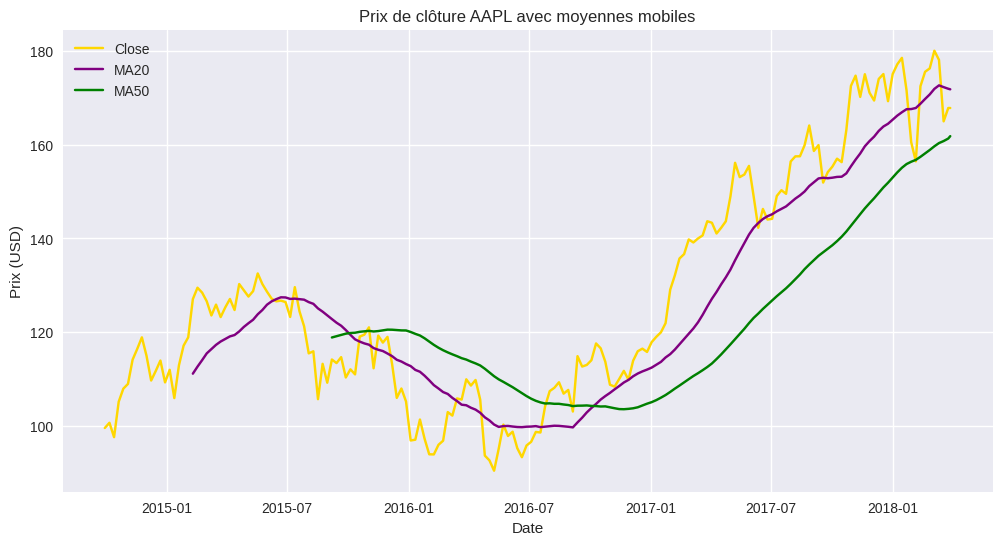

In [37]:
# Visualisations avec Matplotlib

#  Prix de clôture avec moyennes mobiles
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close', color='Gold')
plt.plot(df['Date'], df['MA20'], label='MA20', color='Purple')
plt.plot(df['Date'], df['MA50'], label='MA50', color='green')
plt.title("Prix de clôture AAPL avec moyennes mobiles")
plt.xlabel("Date")
plt.ylabel("Prix (USD)")
plt.legend()
plt.grid(True)
plt.show()

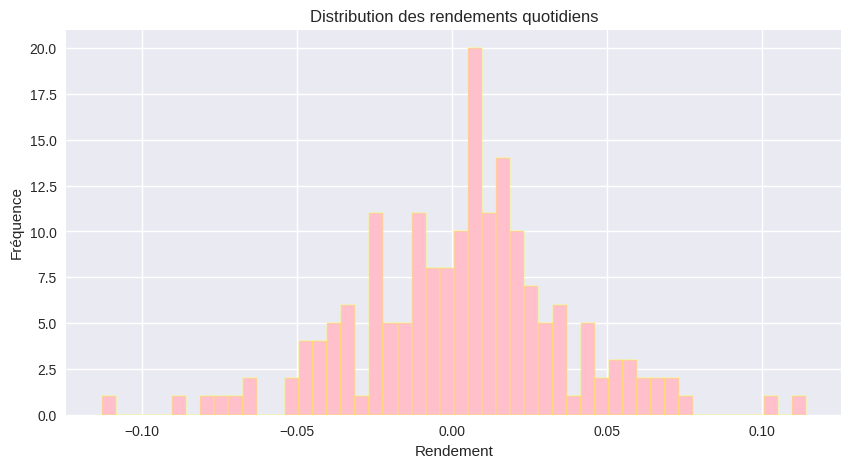

In [38]:
#  Histogramme des rendements quotidiens
plt.figure(figsize=(10,5))
plt.hist(df['Daily_Return'].dropna(), bins=50, color='Pink', edgecolor='Yellow')
plt.title("Distribution des rendements quotidiens")
plt.xlabel("Rendement")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()

In [39]:
# Visualisations interactives avec Plotly
# Graphique interactif du prix de clôture
fig = px.line(df, x='Date', y='Close', title='Prix de clôture AAPL', labels={'Close':'Prix (USD)'})
fig.show()

In [40]:
#  Graphique en chandelier (candlestick)
fig = go.Figure(data=[go.Candlestick(x=df['Date'],
open=df['Open'], high=df['High'],
low=df['Low'], close=df['Close'])])
fig.update_layout(title='Chandeliers AAPL', xaxis_title='Date', yaxis_title='Prix (USD)')
fig.show()

In [41]:
#  Histogramme interactif des rendements
fig = px.histogram(df, x='Daily_Return', nbins=50, title="Distribution des rendements quotidiens",
labels={'Daily_Return':'Rendement'})
fig.show()

In [42]:
# Importer les bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from google.colab import files

In [43]:
# Charger le dataset cars
uploaded = files.upload()
df = pd.read_csv('cars.csv')


Saving cars.csv to cars (1).csv


In [44]:
# Vérification du dataset
print("Dataset Cars chargé avec succès !")
print("Dimensions :", df.shape)
print("Colonnes :", df.columns)
print(df.head())


Dataset Cars chargé avec succès !
Dimensions : (15411, 14)
Colonnes : Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'price'],
      dtype='object')
   Unnamed: 0       car_name    brand     model  vehicle_age  km_driven  \
0           0    Maruti Alto   Maruti      Alto            9     120000   
1           1  Hyundai Grand  Hyundai     Grand            5      20000   
2           2    Hyundai i20  Hyundai       i20           11      60000   
3           3    Maruti Alto   Maruti      Alto            9      37000   
4           4  Ford Ecosport     Ford  Ecosport            6      30000   

  seller_type fuel_type transmission_type  mileage  engine  max_power  seats  \
0  Individual    Petrol            Manual    19.70     796      46.30      5   
1  Individual    Petrol            Manual    18.90    1197      82.00      5   
2  Individual    Petro

In [45]:
# Informations générales
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  price              15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB
None
         Unnamed: 0   vehicle_age     km_driven       mi

In [46]:
# Nettoyage : suppression des valeurs manquantes
df = df.dropna()


In [47]:
# Statistiques descriptives
mean_price = np.mean(df['price'])
median_price = np.median(df['price'])
std_price = np.std(df['price'])
mean_km = np.mean(df['km_driven'])
print(f"Prix moyen : {mean_price:.2f}, Prix médian : {median_price:.2f}, Écart-type : {std_price:.2f}")
print(f"Kilométrage moyen : {mean_km:.2f} km")

Prix moyen : 774971.12, Prix médian : 556000.00, Écart-type : 894099.35
Kilométrage moyen : 55616.48 km


In [48]:
# Création de nouvelles colonnes si besoin : par exemple prix par km
df['price_per_km'] = df['price'] / (df['km_driven']+1)  # +1 pour éviter division par zéro

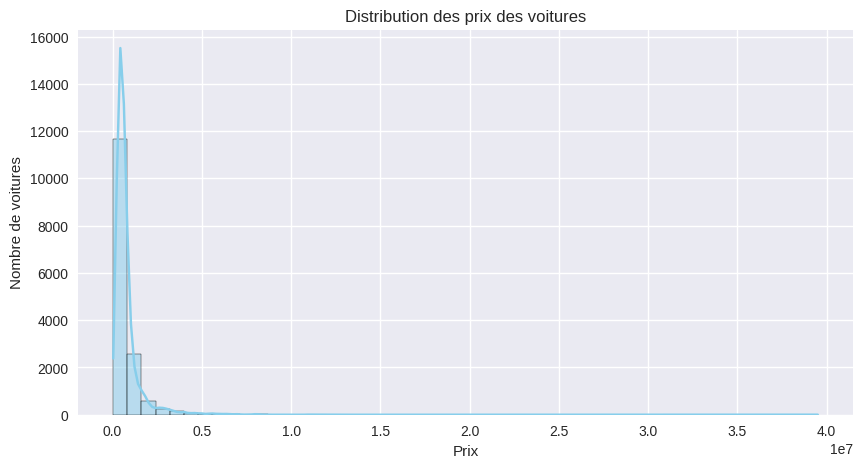

In [49]:
# Visualisations avec Matplotlib / Seaborn

# Histogramme du prix des voitures
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50, kde=True, color='skyblue')
plt.title("Distribution des prix des voitures")
plt.xlabel("Prix")
plt.ylabel("Nombre de voitures")
plt.show()

/tmp/ipython-input-1883640666.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




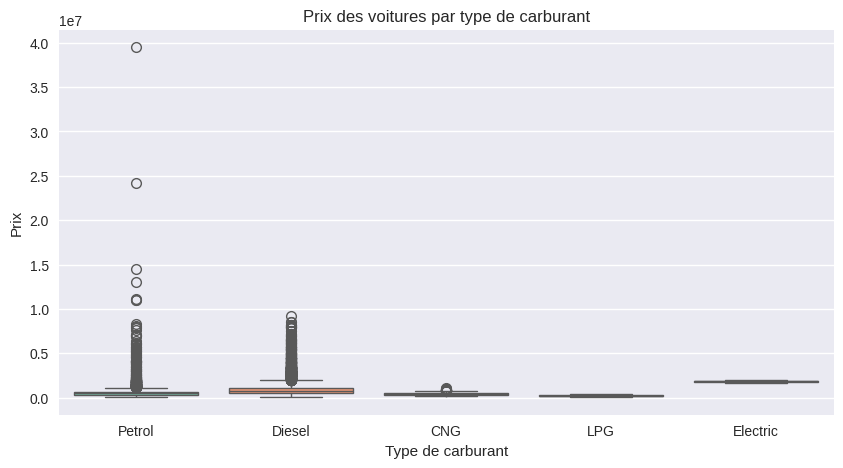

In [50]:
# Boxplot du prix par type de carburant
plt.figure(figsize=(10,5))
sns.boxplot(x='fuel_type', y='price', data=df, palette='Set2')
plt.title("Prix des voitures par type de carburant")
plt.xlabel("Type de carburant")
plt.ylabel("Prix")
plt.show()


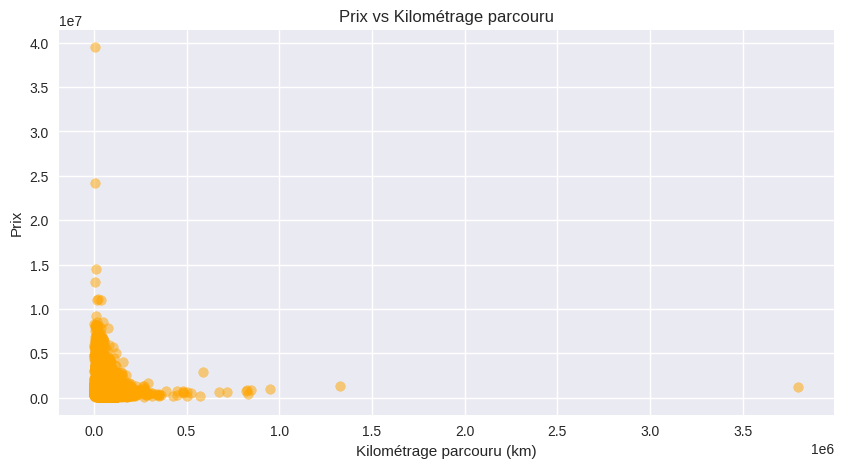

In [51]:
# Scatter plot : prix vs kilométrage
plt.figure(figsize=(10,5))
plt.scatter(df['km_driven'], df['price'], alpha=0.5, color='orange')
plt.title("Prix vs Kilométrage parcouru")
plt.xlabel("Kilométrage parcouru (km)")
plt.ylabel("Prix")
plt.grid(True)
plt.show()

In [52]:
# Visualisations interactives avec Plotly

# Histogramme interactif du prix
fig = px.histogram(df, x='price', nbins=50, title="Distribution des prix des voitures")
fig.show()

In [53]:
# Scatter interactif : prix vs âge du véhicule
fig = px.scatter(df, x='vehicle_age', y='price', color='fuel_type',
                 title="Prix vs âge du véhicule",
                 labels={'vehicle_age':'Âge du véhicule (années)', 'price':'Prix'})
fig.show()

In [54]:
# Prix moyen par marque
avg_price_brand = df.groupby('brand')['price'].mean().sort_values(ascending=False)
fig = px.bar(avg_price_brand, x=avg_price_brand.index, y=avg_price_brand.values,
             title="Prix moyen des voitures par marque", labels={'y':'Prix moyen','x':'Marque'})
fig.show()